# Do the Explanations Point at the Tumour?

### Metrics
| Metric | Meaning | Role |
|---|---|---|
| **EPG** | fraction of heatmap energy inside the mask | **primary** (threshold-free) |
| PG | is the single hottest pixel inside the mask? | secondary |
| IoU / Dice | overlap after thresholding | secondary (threshold-dependent) |

### The baseline you must not skip
A uniform, uninformative heatmap scores EPG equal to the tumour's share of the image (~a few %). Every EPG is meaningless without this baseline printed next to it. The notebook computes it.

*Requires: `images.npy` + `masks.npy` (NB1), `manifest_splits.csv` (NB2), and the seed models (NB3b). Attach all three saved outputs.

In [1]:
# Cell 1 — install + imports
!pip install grad-cam==1.5.4 timm --quiet

from pathlib import Path
import numpy as np, pandas as pd
import torch, timm
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, HiResCAM, XGradCAM, LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("WARNING: no GPU — this will be slow. Turn on the T4.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
device: cuda


## Cell 2 — settings

Start with `SEEDS = [42]` to pilot (10 models). Once it looks right, set `[42, 1, 2]` for the full multi-seed result. All five CAM methods are gradient-based and fast; ScoreCAM is deliberately excluded (hundreds of forward passes per image).

In [2]:
# Cell 2 
IN_DIR  = "/kaggle/input"
OUT_DIR = "/kaggle/working/cam"

ARCH  = "resnet18"
SEEDS = [42,1,2]                     # pilot with [42]; then [42, 1, 2]
FOLDS = [0, 1, 2, 3, 4]
CAM_METHODS = ["GradCAM", "GradCAM++", "HiResCAM", "XGradCAM", "LayerCAM"]
IOU_THRESH = 0.5                 # for IoU/Dice;

In [3]:
# Cell 3 — locate inputs
def find(name):
    hits = list(Path(IN_DIR).rglob(name))
    assert hits, f"{name} not found under {IN_DIR}. Attach the right saved output."
    return hits[0]

images   = np.load(find("images.npy"))
masks    = np.load(find("masks.npy"))
manifest = pd.read_csv(find("manifest_splits.csv"))

# the folder that holds the seed models
a_model = find(f"model_{ARCH}_seed{SEEDS[0]}_fold_honest_fold0.pt")
MODEL_DIR = a_model.parent
print("images", images.shape, "| masks", masks.shape)
print("models in:", MODEL_DIR)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

images (3064, 224, 224) | masks (3064, 224, 224)
models in: /kaggle/input/notebooks/souravpaul100304/3b-multiseed/runs_multiseed


## Cell 4 — scoring functions

`localization_scores` returns all four metrics for one heatmap, plus the per-image mask fraction (the uninformative baseline). EPG is the ratio of heatmap energy inside the mask to total energy — it needs no threshold, which is why it's primary.

In [4]:
# Cell 4 — scoring
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

def to_tensor(img_uint8):
    img = img_uint8.astype(np.float32)/255.0
    img = np.stack([img]*3, axis=-1)
    img = (img - IMAGENET_MEAN)/IMAGENET_STD
    return torch.from_numpy(img.transpose(2,0,1))

def localization_scores(cam, mask, thresh=0.5):
    mask = mask.astype(bool)
    total = cam.sum()
    epg = float(cam[mask].sum()/total) if total > 0 else 0.0
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    pg = int(mask[peak])
    binary = cam >= thresh
    inter = np.logical_and(binary, mask).sum()
    union = np.logical_or(binary, mask).sum()
    iou = float(inter/union) if union > 0 else 0.0
    denom = binary.sum() + mask.sum()
    dice = float(2*inter/denom) if denom > 0 else 0.0
    return {"epg": epg, "pg": pg, "iou": iou, "dice": dice,
            "mask_fraction": float(mask.sum()/mask.size)}

CAM_REGISTRY = {"GradCAM":GradCAM, "GradCAM++":GradCAMPlusPlus,
                "HiResCAM":HiResCAM, "XGradCAM":XGradCAM, "LayerCAM":LayerCAM}
print("scoring ready")

scoring ready


## Cell 5 — evaluate one model

Loads a saved model, computes each CAM method on every slice in its test fold, and scores against the mask. **The heatmap explains the class the model actually predicted**, not the ground truth — so a confidently wrong prediction is scored on what it truly looked at, not what it should have.

In [5]:
# Cell 5 — per-model evaluation
def eval_model(seed, split_col, fold):
    ckpt = MODEL_DIR / f"model_{ARCH}_seed{seed}_{split_col}_fold{fold}.pt"
    if not ckpt.exists():
        print("  missing", ckpt.name); return []
    model = timm.create_model(ARCH, pretrained=False, num_classes=3)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.to(device).eval()
    target_layers = [model.layer4[-1]]     # ResNet CAM target

    test_idx = np.where((manifest[split_col]==fold).values)[0]
    labels = manifest["label"].values - 1

    rows = []
    for name in CAM_METHODS:
        cam_engine = CAM_REGISTRY[name](model=model, target_layers=target_layers)
        for i in test_idx:
            x = to_tensor(images[i]).unsqueeze(0).to(device)
            with torch.no_grad():
                pred = int(model(x).argmax(1).item())
            cam = cam_engine(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]
            s = localization_scores(cam, masks[i], IOU_THRESH)
            rows.append({"seed":seed,"split":split_col,"fold":fold,"cam":name,
                         "idx":int(i),"pid":manifest.pid.values[i],
                         "true":int(labels[i]),"pred":pred,
                         "correct":int(pred==labels[i]), **s})
        del cam_engine
    del model; torch.cuda.empty_cache()
    return rows
print("eval_model ready")

eval_model ready


## Cell 6 — run it

Loops over seeds, splits, folds. With one seed this is 10 models × 5 methods. Progress prints per model.

In [6]:
# Cell 6 — run
all_rows = []
for seed in SEEDS:
    for split_col in ["fold_honest","fold_leaky"]:
        for fold in FOLDS:
            r = eval_model(seed, split_col, fold)
            all_rows += r
            if r:
                ep = np.mean([x["epg"] for x in r])
                print(f"seed {seed} {split_col} fold {fold}: {len(r)} rows, mean EPG {ep:.3f}")

df = pd.DataFrame(all_rows)
df.to_csv(Path(OUT_DIR)/"cam_localization.csv", index=False)
print("\nsaved cam_localization.csv,", len(df), "rows")

seed 42 fold_honest fold 0: 3225 rows, mean EPG 0.063
seed 42 fold_honest fold 1: 2680 rows, mean EPG 0.052
seed 42 fold_honest fold 2: 3010 rows, mean EPG 0.065
seed 42 fold_honest fold 3: 3425 rows, mean EPG 0.066
seed 42 fold_honest fold 4: 2980 rows, mean EPG 0.055
seed 42 fold_leaky fold 0: 3065 rows, mean EPG 0.062
seed 42 fold_leaky fold 1: 3065 rows, mean EPG 0.059
seed 42 fold_leaky fold 2: 3065 rows, mean EPG 0.060
seed 42 fold_leaky fold 3: 3065 rows, mean EPG 0.056
seed 42 fold_leaky fold 4: 3060 rows, mean EPG 0.065
seed 1 fold_honest fold 0: 3225 rows, mean EPG 0.057
seed 1 fold_honest fold 1: 2680 rows, mean EPG 0.047
seed 1 fold_honest fold 2: 3010 rows, mean EPG 0.064
seed 1 fold_honest fold 3: 3425 rows, mean EPG 0.067
seed 1 fold_honest fold 4: 2980 rows, mean EPG 0.052
seed 1 fold_leaky fold 0: 3065 rows, mean EPG 0.063
seed 1 fold_leaky fold 1: 3065 rows, mean EPG 0.056
seed 1 fold_leaky fold 2: 3065 rows, mean EPG 0.057
seed 1 fold_leaky fold 3: 3065 rows, mean EP

In [7]:
"""
Diagnostic: is the low EPG (~0.06) real, or an artefact of coarse CAM resolution
vs small masks? Paste as a new cell in Notebook 4 after Cell 6 (needs `images`,
`masks`, `manifest`, `MODEL_DIR`, `to_tensor`, `ARCH`, `device`).

It checks three things:
  1. How small are the masks, really (in the 224-grid and the 7x7 CAM grid)?
  2. Where does CAM energy concentrate - near the tumour or elsewhere?
  3. Does a "concentration" metric (CAM energy in a dilated mask, and EPG at
     native 7x7 resolution) tell a different story than EPG at 224.
"""
import numpy as np, torch, timm
from scipy.ndimage import binary_dilation, zoom
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

seed, split_col, fold = 42, "fold_honest", 0
model = timm.create_model(ARCH, pretrained=False, num_classes=3)
model.load_state_dict(torch.load(MODEL_DIR/f"model_{ARCH}_seed{seed}_{split_col}_fold{fold}.pt",
                                 map_location=device))
model.to(device).eval()
cam_engine = GradCAM(model=model, target_layers=[model.layer4[-1]])

test_idx = np.where((manifest[split_col]==fold).values)[0][:60]

mask_frac_224, mask_frac_7 = [], []
epg_224, epg_dilated, epg_7 = [], [], []
peak_in_mask, peak_in_dilated = [], []

for i in test_idx:
    x = to_tensor(images[i]).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = int(model(x).argmax(1).item())
    cam = cam_engine(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]  # 224x224
    m = masks[i].astype(bool)

    mask_frac_224.append(m.mean())

    # EPG at 224
    epg_224.append(cam[m].sum()/cam.sum() if cam.sum()>0 else 0)

    # EPG with mask dilated ~5 px (does energy sit in a ring around the tumour?)
    md = binary_dilation(m, iterations=5)
    epg_dilated.append(cam[md].sum()/cam.sum() if cam.sum()>0 else 0)

    # Downsample both to 7x7 (native CAM grid) and compute EPG there
    cam7 = zoom(cam, 7/cam.shape[0], order=1)
    m7 = zoom(m.astype(float), 7/m.shape[0], order=1) > 0.5
    mask_frac_7.append(m7.mean())
    epg_7.append(cam7[m7].sum()/cam7.sum() if (cam7.sum()>0 and m7.any()) else 0)

    peak = np.unravel_index(np.argmax(cam), cam.shape)
    peak_in_mask.append(bool(m[peak]))
    peak_in_dilated.append(bool(md[peak]))

f = lambda a: (np.mean(a), np.std(a))
print(f"mask fraction @224 : {np.mean(mask_frac_224):.4f}")
print(f"mask fraction @7x7 : {np.mean(mask_frac_7):.4f}  (baseline at CAM resolution)")
print()
print(f"EPG @224           : {np.mean(epg_224):.4f}")
print(f"EPG @224 dilated+5  : {np.mean(epg_dilated):.4f}  (energy in a ring around tumour)")
print(f"EPG @7x7           : {np.mean(epg_7):.4f}   vs its baseline {np.mean(mask_frac_7):.4f}")
print()
print(f"Peak inside tumour        : {np.mean(peak_in_mask):.2%}")
print(f"Peak inside dilated tumour: {np.mean(peak_in_dilated):.2%}")
print()
print("Interpretation:")
print("- If EPG@7x7 >> its baseline but EPG@224 ~ baseline -> resolution artefact.")
print("- If dilated EPG >> tight EPG -> energy rings the tumour (near but not on).")
print("- If peak-in-mask is high (>50%) -> CAMs DO find the tumour; EPG penalises spread.")
print("- If everything stays near baseline -> the weak localisation is real.")


mask fraction @224 : 0.0187
mask fraction @7x7 : 0.0129  (baseline at CAM resolution)

EPG @224           : 0.0737
EPG @224 dilated+5  : 0.1135  (energy in a ring around tumour)
EPG @7x7           : 0.0658   vs its baseline 0.0129

Peak inside tumour        : 18.33%
Peak inside dilated tumour: 33.33%

Interpretation:
- If EPG@7x7 >> its baseline but EPG@224 ~ baseline -> resolution artefact.
- If dilated EPG >> tight EPG -> energy rings the tumour (near but not on).
- If peak-in-mask is high (>50%) -> CAMs DO find the tumour; EPG penalises spread.
- If everything stays near baseline -> the weak localisation is real.


## Cell 7 — the headline result

EPG for honest vs leaky, per CAM method, with the uninformative baseline. **If honest EPG > leaky EPG** the more-accurate, more-confident leaky models localise the tumour *less*.

Read the baseline first. If any EPG is close to it, that heatmap is essentially uninformative regardless of split.

In [8]:
# Cell 7 — headline table
base = df.mask_fraction.mean()
print(f"Uninformative baseline (mean mask fraction): {base:.4f}")
print("Any EPG near this value means the heatmap carries almost no localisation.\n")

pivot = df.pivot_table(index="cam", columns="split", values="epg", aggfunc="mean")
pivot["honest_minus_leaky"] = pivot["fold_honest"] - pivot["fold_leaky"]
print("Mean EPG by CAM method and split:")
print(pivot.round(4).to_string())

overall_h = df[df.split=="fold_honest"].epg.mean()
overall_l = df[df.split=="fold_leaky"].epg.mean()
print(f"\nOverall EPG  honest {overall_h:.4f}  vs  leaky {overall_l:.4f}  "
      f"(diff {overall_h-overall_l:+.4f})")

Uninformative baseline (mean mask fraction): 0.0169
Any EPG near this value means the heatmap carries almost no localisation.

Mean EPG by CAM method and split:
split      fold_honest  fold_leaky  honest_minus_leaky
cam                                                   
GradCAM         0.0583      0.0587             -0.0004
GradCAM++       0.0574      0.0575             -0.0002
HiResCAM        0.0583      0.0587             -0.0004
LayerCAM        0.0568      0.0569             -0.0001
XGradCAM        0.0583      0.0587             -0.0004

Overall EPG  honest 0.0578  vs  leaky 0.0581  (diff -0.0003)


## Cell 8 — supporting breakdowns

**Pointing Game** — a coarser, intuitive check (is the peak on the tumour?).

**Correct vs incorrect** — does the heatmap look as tumour-focused when the model is *wrong*? If EPG is similar for right and wrong predictions, that's a second finding: the explanation is equally convincing when the model errs.

In [9]:
# Cell 8 — breakdowns
print("Pointing Game (peak inside tumour) by split and method:")
print(df.pivot_table(index="cam", columns="split", values="pg",
                     aggfunc="mean").round(4).to_string())

print("\nEPG by whether the prediction was correct:")
print(df.pivot_table(index="split", columns="correct", values="epg",
                     aggfunc="mean").round(4).to_string())

# Patient-level means (statistics should be per-patient, not per-slice)
pat = (df[df.cam=="GradCAM"].groupby(["split","pid"]).epg.mean().reset_index())
print("\nGrad-CAM EPG, patient-level mean by split:")
print(pat.groupby("split").epg.agg(["mean","std","count"]).round(4).to_string())

Pointing Game (peak inside tumour) by split and method:
split      fold_honest  fold_leaky
cam                               
GradCAM         0.1472      0.1614
GradCAM++       0.1596      0.1748
HiResCAM        0.1472      0.1614
LayerCAM        0.1591      0.1727
XGradCAM        0.1472      0.1614

EPG by whether the prediction was correct:
correct           0       1
split                      
fold_honest  0.0410  0.0589
fold_leaky   0.0332  0.0586

Grad-CAM EPG, patient-level mean by split:
               mean     std  count
split                             
fold_honest  0.0511  0.0421    233
fold_leaky   0.0520  0.0431    233


## Cell 9 — visual comparison

Runs the honest and the leaky fold-0 model on the *same* slices (unseen by the honest model) and shows both heatmaps with the tumour outlined. This is illustrative — the quantitative claim lives in the tables — but it's the figure readers remember.

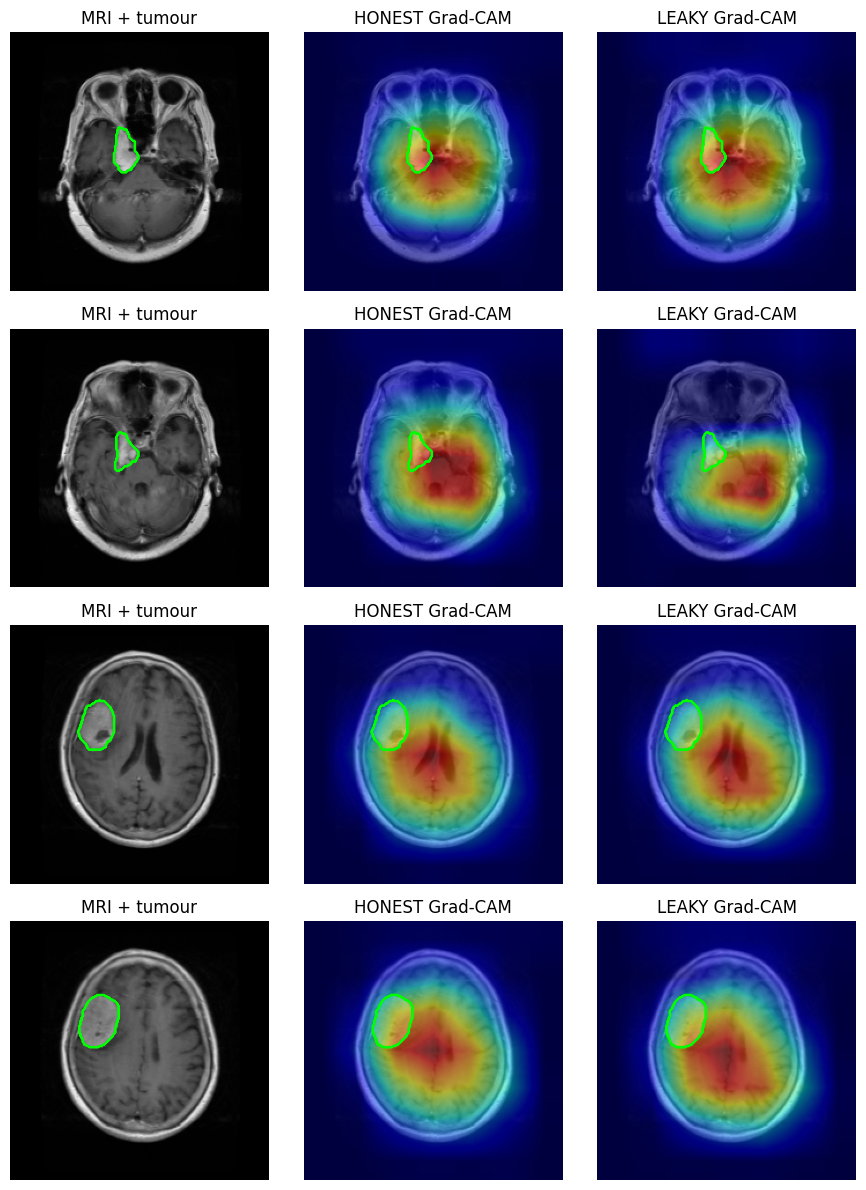

saved heatmap_comparison.png


In [10]:
# Cell 9 — side-by-side heatmaps
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM

def load(seed, split_col, fold):
    m = timm.create_model(ARCH, pretrained=False, num_classes=3)
    m.load_state_dict(torch.load(MODEL_DIR/f"model_{ARCH}_seed{seed}_{split_col}_fold{fold}.pt",
                                 map_location=device))
    return m.to(device).eval()

seed = SEEDS[0]
m_h, m_l = load(seed,"fold_honest",0), load(seed,"fold_leaky",0)
cam_h = GradCAM(model=m_h, target_layers=[m_h.layer4[-1]])
cam_l = GradCAM(model=m_l, target_layers=[m_l.layer4[-1]])

show = np.where((manifest["fold_honest"]==0).values)[0][:4]
fig, axes = plt.subplots(len(show), 3, figsize=(9, 3*len(show)))
for r, i in enumerate(show):
    x = to_tensor(images[i]).unsqueeze(0).to(device)
    ph = int(m_h(x).argmax(1)); pl = int(m_l(x).argmax(1))
    ch = cam_h(input_tensor=x, targets=[ClassifierOutputTarget(ph)])[0]
    cl = cam_l(input_tensor=x, targets=[ClassifierOutputTarget(pl)])[0]
    axes[r,0].imshow(images[i], cmap="gray"); axes[r,0].contour(masks[i], colors="lime", linewidths=1)
    axes[r,0].set_title("MRI + tumour"); 
    axes[r,1].imshow(images[i], cmap="gray"); axes[r,1].imshow(ch, cmap="jet", alpha=0.5)
    axes[r,1].contour(masks[i], colors="lime", linewidths=1); axes[r,1].set_title("HONEST Grad-CAM")
    axes[r,2].imshow(images[i], cmap="gray"); axes[r,2].imshow(cl, cmap="jet", alpha=0.5)
    axes[r,2].contour(masks[i], colors="lime", linewidths=1); axes[r,2].set_title("LEAKY Grad-CAM")
    for c in range(3): axes[r,c].axis("off")
plt.tight_layout(); plt.savefig(Path(OUT_DIR)/"heatmap_comparison.png", dpi=130); plt.show()
print("saved heatmap_comparison.png")